# Phase 4 : Modélisation et Clustering (Volet 2)

## Introduction
Suite à notre Analyse en Composantes Principales (ACP) qui nous a permis de comprendre les relations entre nos variables (notamment le lien fort entre l'historique de bananes, la position géographique et le taux de chlordécone), nous passons à la phase de classification.

L'objectif de cette section est de répondre aux exigences d'aide à la décision du projet : **identifier des profils de territoires et des zones à risque**. 

---

### 1. Préparation des données et Méthode du Coude (Elbow Method)
Nous allons utiliser l'algorithme de classification non supervisée **K-Means** (Centres mobiles). La première étape de cet algorithme consiste à déterminer le nombre optimal de clusters ($K$). 

Pour ce faire, nous appliquons la méthode du coude : nous testons plusieurs valeurs de $K$ (de 1 à 10) et calculons l'inertie intra-classe (la dispersion à l'intérieur des groupes). Le point d'inflexion (la cassure ou "coude" de la courbe) nous indiquera le nombre idéal de profils à retenir.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# 1. Chargement des données propres
df = pd.read_csv('chlordecone_clean.csv')

In [4]:
# 2. Sélection des variables quantitatives (identique à l'ACP)
colonnes_num = df.select_dtypes(include=['float64', 'int64']).columns
colonnes_a_garder = [col for col in colonnes_num if col not in ['ID', 'ANNEE']]
df_num = df[colonnes_a_garder]

In [5]:
# 3. Standardisation des données (Indispensable pour le calcul des distances K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

In [8]:
# 4. Calcul de l'inertie pour K allant de 1 à 10
inerties = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 est une bonne pratique pour éviter de tomber dans un minimum local
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inerties.append(kmeans.inertia_)

print("Inerties pour K de 1 à 10 :", inerties)

Inerties pour K de 1 à 10 : [331419.00000000047, 278667.1699570853, 245677.32571869678, 215647.43443699228, 196230.8633012073, 180115.84513136526, 166350.49335015338, 157156.77356865304, 148303.21446667984, 141127.01994159416]


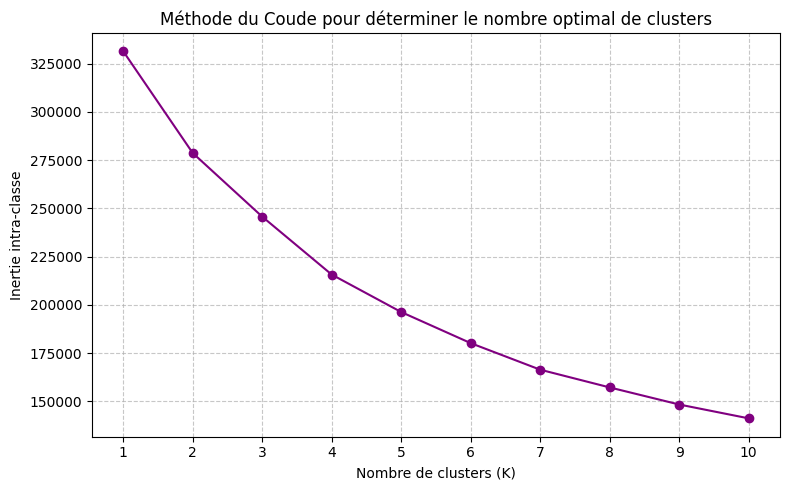

In [7]:
# 5. Création du graphique du Coude
plt.figure(figsize=(8, 5))
plt.plot(K_range, inerties, marker='o', color='purple', linestyle='-')
plt.title('Méthode du Coude pour déterminer le nombre optimal de clusters')
plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie intra-classe')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()